### RAG Pipeline: Chunking, Vector Search, RerankingThe three stages of a retrieval-augmented-generation pipeline's retrieval side, in the order they run: split source documents into chunks, embed and index them for approximate nearest-neighbor (ANN) search, then rerank the retrieved candidates before handing them to the LLM. See `llm-evals.ipynb` for how to measure whether the retrieval stage is actually working (Precision@k, Recall@k, MRR, NDCG, RAGAS).

#### 1. Chunking strategiesCharacter/token-based chunking (fixed size + overlap), sentence-aware splitting, semantic chunking (split where consecutive sentences' embeddings diverge, not at a fixed size), and AST-based chunking for code (split at function/class boundaries instead of arbitrary character counts, so a chunk never cuts a function definition in half).

In [3]:
import re, json
import numpy as np
import pandas as pd
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, CrossEncoder
import litellm

/Users/monusingh/work-share/code-blogs-articles/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
sample_doc = """
Machine learning is a subset of artificial intelligence that enables systems to learn from data.
It uses statistical techniques to give computers the ability to improve with experience.
Supervised learning requires labeled training data to make predictions.
The model learns a mapping from inputs to outputs based on example pairs.

Neural networks are computing systems inspired by biological neural networks in animal brains.
They consist of layers of interconnected nodes that process information using connectionist approaches.
Deep learning uses many layers to learn hierarchical representations of data.
Convolutional networks are especially effective for image recognition tasks.

Natural language processing allows machines to understand and generate human language.
Transformers have revolutionized NLP by using self-attention mechanisms.
BERT and GPT are prominent examples of transformer-based language models.
These models are pretrained on massive corpora and then fine-tuned for specific tasks.
"""

In [ ]:
def character_chunk(text: str, size: int = 200, overlap: int = 20) -> List[str]:
    chunks = []
    start = 0
    while start < len(text):
        chunks.append(text[start : start + size])
        start += size - overlap
    return [c.strip() for c in chunks if c.strip()]

def word_chunk(text: str, size: int = 50, overlap: int = 10) -> List[str]:
    words = text.split()
    chunks = []
    for i in range(0, len(words), size - overlap):
        chunks.append(" ".join(words[i : i + size]))
    return [c for c in chunks if c.strip()]

def sentence_chunk(text: str, sentences_per_chunk: int = 2) -> List[str]:
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s for s in sentences if s.strip()]
    chunks = []
    for i in range(0, len(sentences), sentences_per_chunk):
        chunks.append(" ".join(sentences[i : i + sentences_per_chunk]))
    return chunks

def paragraph_chunk(text: str) -> List[str]:
    # splits on blank lines
    paragraphs = re.split(r'\n\s*\n', text.strip())
    return [p.strip() for p in paragraphs if p.strip()]

def recursive_chunk(text: str, size: int = 200, overlap: int = 20,
                    separators: List[str] = ["\n\n", "\n", ". ", " ", ""]) -> List[str]:
    for sep in separators:
        parts = text.split(sep) if sep else list(text)
        parts = [p for p in parts if p.strip()]
        # if splitting produces reasonably sized pieces, use it
        if all(len(p) <= size * 1.5 for p in parts):
            # merge small adjacent parts up to `size`
            chunks, current = [], ""
            for part in parts:
                candidate = (current + sep + part).strip() if current else part
                if len(candidate) <= size:
                    current = candidate
                else:
                    if current:
                        chunks.append(current)
                    current = part
            if current:
                chunks.append(current)
            return chunks
    return [text]

model = SentenceTransformer("all-MiniLM-L6-v2")

def semantic_chunk(text: str, threshold: float = 0.5) -> List[str]:
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s for s in sentences if s.strip()]
    embeddings = model.encode(sentences)

    chunks, current = [], [sentences[0]]
    for i in range(1, len(sentences)):
        sim = cosine_similarity([embeddings[i-1]], [embeddings[i]])[0][0]
        if sim < threshold:
            chunks.append(" ".join(current))
            current = []
        current.append(sentences[i])

    if current:
        chunks.append(" ".join(current))
    return chunks

In [9]:
strategies = {
    "Character (200, ov=20)":  character_chunk(sample_doc, size=200, overlap=20),
    "Word (50w, ov=10)":       word_chunk(sample_doc, size=50, overlap=10),
    "Sentence (2 per chunk)":  sentence_chunk(sample_doc, sentences_per_chunk=2),
    "Paragraph":               paragraph_chunk(sample_doc),
    "Recursive (200)":         recursive_chunk(sample_doc, size=200),
    "Semantic (t=0.5)":        semantic_chunk(sample_doc, threshold=0.5),
}

rows = []
for name, chunks in strategies.items():
    lengths = [len(c) for c in chunks]
    rows.append({
        "Strategy":    name,
        "Num Chunks":  len(chunks),
        "Min Chars":   min(lengths),
        "Max Chars":   max(lengths),
        "Avg Chars":   round(np.mean(lengths)),
        "Std Dev":     round(np.std(lengths)),
    })

df = pd.DataFrame(rows).set_index("Strategy")
print(df.to_string())

                        Num Chunks  Min Chars  Max Chars  Avg Chars  Std Dev
Strategy                                                                    
Character (200, ov=20)           6        109        200        185       34
Word (50w, ov=10)                4        133        395        305      102
Sentence (2 per chunk)           6        145        198        167       18
Paragraph                        3        320        353        335       14
Recursive (200)                  6        145        198        167       18
Semantic (t=0.5)                 9         71        233        111       49


In [16]:
from langchain_text_splitters import (          # ← new package
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter,
    SentenceTransformersTokenTextSplitter,
)
from langchain_experimental.text_splitter import SemanticChunker
from langchain_community.embeddings import HuggingFaceEmbeddings

# 1. Character
char_splitter = CharacterTextSplitter(chunk_size=200, chunk_overlap=20)

# 2. Recursive (default in most LangChain RAG pipelines)
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=20,
    separators=["\n\n", "\n", ". ", " ", ""]
)

# 3. Token-aware (respects model token limits)
token_splitter = SentenceTransformersTokenTextSplitter(
    model_name="all-MiniLM-L6-v2",
    chunk_overlap=10
)

# 4. Semantic (uses embeddings, equivalent to what we built manually)
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
semantic_splitter = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile",   # or "standard_deviation", "interquartile"
    breakpoint_threshold_amount=85
)

chunks = semantic_splitter.split_text(sample_doc)

/var/folders/0l/p7lzlqxn44b036b_3ykx4tlr0000gn/T/ipykernel_6552/1295058332.py:6: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.text_splitter import SemanticChunker
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1495.20it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/var/folders/0l/p7lzlqxn44b036b_3ykx4tlr0000gn/T/ipykernel_6552/1295058332.py:26: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updat

In [18]:
from llama_index.core.node_parser import (
    SentenceSplitter,
    SemanticSplitterNodeParser,
    TokenTextSplitter,
    MarkdownNodeParser,
    CodeSplitter,                  # language-aware splitting for code
)
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

embed_model = HuggingFaceEmbedding(model_name="all-MiniLM-L6-v2")

# Sentence-aware splitter (most common default in LlamaIndex)
sentence_parser = SentenceSplitter(chunk_size=256, chunk_overlap=20)

# Semantic splitter
semantic_parser = SemanticSplitterNodeParser(
    buffer_size=1,                 # sentences to look ahead/behind
    breakpoint_percentile_threshold=95,
    embed_model=embed_model
)

from llama_index.core import Document
doc = Document(text=sample_doc)
nodes = semantic_parser.get_nodes_from_documents([doc])
chunks = [n.get_content() for n in nodes]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1643.32it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
chunks

['\nMachine learning is a subset of artificial intelligence that enables systems to learn from data.\nIt uses statistical techniques to give computers the ability to improve with experience.\nSupervised learning requires labeled training data to make predictions.\nThe model learns a mapping from inputs to outputs based on example pairs.\n\nNeural networks are computing systems inspired by biological neural networks in animal brains.\nThey consist of layers of interconnected nodes that process information using connectionist approaches.\nDeep learning uses many layers to learn hierarchical representations of data.\nConvolutional networks are especially effective for image recognition tasks.\n\nNatural language processing allows machines to understand and generate human language.\n',
 'Transformers have revolutionized NLP by using self-attention mechanisms.\nBERT and GPT are prominent examples of transformer-based language models.\nThese models are pretrained on massive corpora and then 

#### Semantic chunking via similarity threshold

A manual implementation: walk sentences, start a new chunk whenever cosine similarity to the previous sentence drops below a threshold.


In [5]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "LLMs have limited context windows.",
    "This makes naive prompt stuffing impractical.",
    "So we rely on retrieval-augmented generation (RAG) to bring only relevant context.",
    "Chunking is a core retrieval strategy in RAG pipelines.",
    "Chunks are embedded into vectors that capture semantic meaning.",
    "Vector databases store embeddings efficiently and support fast lookup.",
    "At query time, approximate nearest neighbor (ANN) search retrieves candidate chunks.",
    "A reranker can reorder retrieved chunks for higher precision.",
    "Monitoring is critical once models are deployed.",
    "You track latency, quality drift, and retrieval hit-rates to catch regressions early.",
]

embeddings = model.encode(sentences)

SIM_THRESHOLD = 0.55

chunks = []
current_chunk = [sentences[0]]

for i in range(1, len(sentences)):
    sim = cosine_similarity(
        embeddings[i-1].reshape(1, -1),
        embeddings[i].reshape(1, -1)
    )[0][0]

    if sim < SIM_THRESHOLD:
        chunks.append(" ".join(current_chunk))
        current_chunk = [sentences[i]]
    else:
        current_chunk.append(sentences[i])

chunks.append(" ".join(current_chunk))

for i, c in enumerate(chunks):
    print(f"\n--- Chunk {i+1} ---\n{c}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Chunk 1 ---
LLMs have limited context windows.

--- Chunk 2 ---
This makes naive prompt stuffing impractical.

--- Chunk 3 ---
So we rely on retrieval-augmented generation (RAG) to bring only relevant context. Chunking is a core retrieval strategy in RAG pipelines.

--- Chunk 4 ---
Chunks are embedded into vectors that capture semantic meaning.

--- Chunk 5 ---
Vector databases store embeddings efficiently and support fast lookup.

--- Chunk 6 ---
At query time, approximate nearest neighbor (ANN) search retrieves candidate chunks. A reranker can reorder retrieved chunks for higher precision.

--- Chunk 7 ---
Monitoring is critical once models are deployed.

--- Chunk 8 ---
You track latency, quality drift, and retrieval hit-rates to catch regressions early.


#### AST-based code chunking

For code, splitting on characters/tokens risks cutting a function or class in half. Parse to an AST and chunk on `ClassDef`/`FunctionDef` boundaries instead.


In [6]:
import ast

code = """
class CreditScorer:
    def __init__(self, model):
        self.model = model

    def preprocess(self, data):
        return data.fillna(0)

    def score(self, data):
        data = self.preprocess(data)
        return self.model.predict(data)

def helper(x):
    return x * 2
"""

tree = ast.parse(code)

chunks = []

for node in tree.body:
    if isinstance(node, (ast.ClassDef, ast.FunctionDef)):
        chunk = ast.get_source_segment(code, node)
        chunks.append(chunk)

for i, c in enumerate(chunks):
    print(f"\n--- Code Chunk {i+1} ---\n{c}")


--- Code Chunk 1 ---
class CreditScorer:
    def __init__(self, model):
        self.model = model

    def preprocess(self, data):
        return data.fillna(0)

    def score(self, data):
        data = self.preprocess(data)
        return self.model.predict(data)

--- Code Chunk 2 ---
def helper(x):
    return x * 2


#### 2. Embedding and ANN vector searchChunks from above get embedded and indexed for fast approximate nearest-neighbor search (FAISS here), the retrieval step a RAG pipeline actually runs at query time. Benchmarks recall vs. latency across FAISS's `efSearch` parameter, the accuracy/speed tradeoff every ANN index has to make (exact search doesn't scale, approximate search trades a small accuracy loss for large speedups).

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# macOS-only fix: faiss and torch (pulled in later by sentence-transformers) each
# bundle their own OpenMP runtime; loading both aborts the process without this.
# Must be set before faiss/torch are imported anywhere in the notebook.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"  # silence the weight-loading progress bar noise

import faiss
import numpy as np


d = 384                      # embedding dim, e.g. all-MiniLM-L6-v2
xb = np.random.rand(100_000, d).astype("float32")  # your corpus embeddings

# --- exact baseline ---
index_flat = faiss.IndexFlatIP(d)     # inner product; use IndexFlatL2 for L2
index_flat.add(xb)

# --- HNSW: best default for RAG-scale corpora (10^4 - 10^7 vectors) ---
index_hnsw = faiss.IndexHNSWFlat(d, 32)     # M = 32 links per node
index_hnsw.hnsw.efConstruction = 200        # build-time search breadth
index_hnsw.add(xb)
index_hnsw.hnsw.efSearch = 64               # query-time search breadth (recall/latency knob)
# live per query knob

# --- IVF-PQ: for 10^7+ vectors where RAM is the constraint ---
quantizer = faiss.IndexFlatIP(d)
index_ivfpq = faiss.IndexIVFPQ(quantizer, d, 4096, 8, 8)  # nlist=4096, m=8 subquantizers, 8 bits
index_ivfpq.train(xb)
index_ivfpq.add(xb)
index_ivfpq.nprobe = 16                     # cells searched per query

query = np.random.rand(1, d).astype("float32")
D, I = index_hnsw.search(query, k=5)        # returns distances, indices of top-5

WARNING clustering 100000 points to 4096 centroids: please provide at least 159744 training points


In [2]:
from sentence_transformers import SentenceTransformer

# 15 real sentences across 3 clear topics -- these are the "correct" chunks a RAG
# system should retrieve. Everything else in the corpus is noise standing in for
# the rest of a big real-world corpus that's irrelevant to any given query.
docs = [
    "Gradient descent updates model weights by moving against the loss gradient.",
    "Backpropagation computes gradients layer by layer using the chain rule.",
    "Overfitting happens when a model memorizes training data instead of generalizing.",
    "Regularization techniques like dropout and weight decay reduce overfitting.",
    "Neural networks stack layers of weighted connections to learn representations.",

    "A primary key uniquely identifies each row in a relational database table.",
    "Indexes speed up database queries by avoiding full table scans.",
    "Normalization organizes tables to reduce data redundancy.",
    "SQL joins combine rows from two or more tables based on a related column.",
    "Transactions in a database guarantee atomicity and consistency of writes.",

    "A striker's job is to score goals and finish attacking chances.",
    "Midfielders control possession and link defense with attack.",
    "A well-organized defense limits the opponent's shots on goal.",
    "Set pieces like corners and free kicks create scoring opportunities.",
    "Goalkeepers must command their box and organize the defensive line.",
]

model = SentenceTransformer("all-MiniLM-L6-v2")
doc_vecs = model.encode(docs, normalize_embeddings=True).astype("float32")
d = doc_vecs.shape[1]

# pad with random unit vectors -- without this, 15 vectors is a trivial search.
# real embeddings cluster tightly by meaning; random vectors in 384 dims sit far
# apart from everything, so the true docs still stand out as genuine nearest neighbors.
rng = np.random.default_rng(0)
noise = rng.normal(size=(20_000, d)).astype("float32")
noise /= np.linalg.norm(noise, axis=1, keepdims=True)

xb = np.vstack([doc_vecs, noise])   # docs occupy indices [0, 15)
print(xb.shape)


/Users/monusingh/work-share/code-blogs-articles/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(20015, 384)


In [3]:
import faiss

# hand-labeled ground truth: for each question, which doc index should come back.
# this is the same shape as a real RAG eval set -- (query, id_of_the_chunk_that_should_be_retrieved)
queries = [
    ("How does backpropagation compute gradients?", 1),
    ("What does a database index do?", 6),
    ("What is a midfielder responsible for?", 11),
]
query_vecs = model.encode([q for q, _ in queries], normalize_embeddings=True).astype("float32")

# ground truth = exact, brute-force search over the FULL corpus (15 docs + 20,000 noise vectors)
index_flat = faiss.IndexFlatIP(d)
index_flat.add(xb)

k = 10
gt_D, gt_I = index_flat.search(query_vecs, k)

for (question, expected_idx), neighbors in zip(queries, gt_I):
    rank = list(neighbors).index(expected_idx) if expected_idx in neighbors else None
    print(f"{question!r:55s} expected doc {expected_idx:2d} -> found at rank {rank}")


'How does backpropagation compute gradients?'           expected doc  1 -> found at rank 0
'What does a database index do?'                        expected doc  6 -> found at rank 0
'What is a midfielder responsible for?'                 expected doc 11 -> found at rank 0


In [4]:
import time

# use every doc's own embedding as a query -- gives 15 query points instead of 3,
# enough to see a real recall curve instead of jumps of 33%
gt_D, gt_I = index_flat.search(doc_vecs, k)   # ground truth: true top-k for each doc, over the full corpus

index_hnsw = faiss.IndexHNSWFlat(d, 32)       # M = 32
index_hnsw.hnsw.efConstruction = 200
index_hnsw.add(xb)

ef_values = [4, 8, 16, 32, 64, 128, 256]
results = []

for ef in ef_values:
    index_hnsw.hnsw.efSearch = ef
    start = time.perf_counter()
    ann_D, ann_I = index_hnsw.search(doc_vecs, k)
    elapsed_ms = (time.perf_counter() - start) * 1000 / len(doc_vecs)

    # recall@k: of the true top-k neighbors, what fraction did HNSW actually return?
    hits = sum(len(set(gt_I[i]) & set(ann_I[i])) for i in range(len(doc_vecs)))
    recall = hits / (len(doc_vecs) * k)

    results.append((ef, recall, elapsed_ms))
    print(f"efSearch={ef:4d}  recall@{k}={recall:.3f}  avg query time={elapsed_ms:.3f} ms")


efSearch=   4  recall@10=0.980  avg query time=0.023 ms
efSearch=   8  recall@10=0.987  avg query time=0.026 ms
efSearch=  16  recall@10=0.993  avg query time=0.038 ms
efSearch=  32  recall@10=0.993  avg query time=0.065 ms
efSearch=  64  recall@10=0.993  avg query time=0.124 ms
efSearch= 128  recall@10=1.000  avg query time=0.236 ms
efSearch= 256  recall@10=1.000  avg query time=0.393 ms


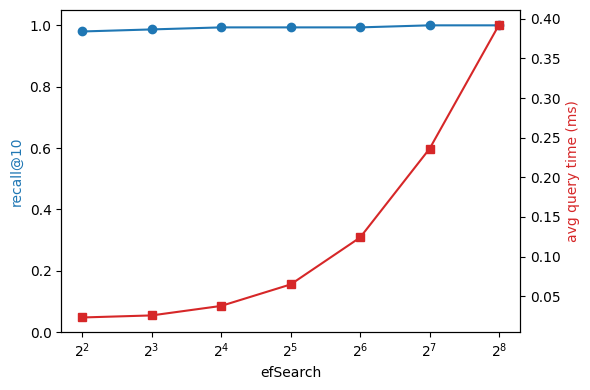

In [5]:
import matplotlib.pyplot as plt

efs, recalls, latencies = zip(*results)

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(efs, recalls, marker="o", color="tab:blue")
ax1.set_xlabel("efSearch")
ax1.set_ylabel("recall@10", color="tab:blue")
ax1.set_xscale("log", base=2)
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(efs, latencies, marker="s", color="tab:red")
ax2.set_ylabel("avg query time (ms)", color="tab:red")

fig.tight_layout()
plt.show()


#### 3. Reranking retrieved contextANN search above optimizes for speed over a huge candidate pool, using a cheap similarity metric (cosine similarity over bi-encoder embeddings). Reranking takes the top candidates from that first pass and re-scores them with a more expensive, more accurate cross-encoder, jointly encoding query and candidate together rather than comparing separately-computed embeddings, catching relevance ANN's cheaper first pass missed.

In [1]:
!pip install sentence_transformers==5.2.2 numpy==2.0.2 scikit-learn==1.6.1 llmlingua==0.2.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 13.3 MB/s eta 0:00:0000:01
  Attempting uninstall: sentence_transformers
    Found existing installation: sentence-transformers 5.2.3
    Uninstalling sentence-transformers-5.2.3:
      Successfully uninstalled sentence-transformers-5.2.3


In [7]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer, CrossEncoder


# Sample corpus (already chunked)
chunks = [
    # Chunk 0
    "Chunking is how we split long documents into smaller pieces so retrieval works within an LLM’s context window. "
    "A chunk should be big enough to be meaningful but small enough to fit alongside other evidence.",

    # Chunk 1
    "Fixed-size chunking (e.g., every 500 tokens) is simple but often cuts semantic units and loses coherence. "
    "Overlaps can reduce boundary loss but increase index size.",

    # Chunk 2
    "Semantic chunking uses embeddings to detect topic shifts between adjacent sentences. "
    "When similarity drops below a threshold, we create a boundary.",

    # Chunk 3
    "For codebases, text chunking is risky because splitting mid-function breaks syntax and meaning. "
    "AST-based chunking keeps functions and classes intact.",

    # Chunk 4
    "Vector search is usually a high-recall candidate generator. "
    "To improve precision, we re-rank retrieved chunks with a cross-encoder that jointly reads query and chunk.",

    # Chunk 5
    "Context compression reduces prompt size by removing low-information tokens. "
    "One approach uses a smaller LM to estimate token predictability and prune highly predictable tokens.",

    # Chunk 6 (distractor)
    "Monitoring in production includes latency, cost, quality, and drift. "
    "Feedback loops can trigger retraining or data refresh.",

    # Chunk 7 (distractor)
    "Prompt templates help standardize outputs. "
    "They can include instructions, examples, and structured formatting constraints."
]

# Query
query = "How do we chunk documents for LLMs?"

print("QUERY")
print(query)

# Bi-encoder retrieval (candidate generation)
print("STAGE 1: BI-ENCODER RETRIEVAL")

bi_encoder = SentenceTransformer("all-MiniLM-L6-v2")

chunk_embeddings = bi_encoder.encode(
    chunks,
    normalize_embeddings=True
)

query_embedding = bi_encoder.encode(
    [query],
    normalize_embeddings=True
)

scores = cosine_similarity(query_embedding, chunk_embeddings)[0]

print("\nCosine similarity vs each chunk:")
for i, s in enumerate(scores):
    print(f"  chunk[{i}]  score={s:.4f}  | {chunks[i][:80]}...")

# Select top-k candidates
top_k = 6
top_indices = np.argsort(scores)[-top_k:][::-1]

candidates = [
    (i, chunks[i], float(scores[i]))
    for i in top_indices
]

print(f"\nTop-{top_k} candidates:")
for rank, (idx, text, score) in enumerate(candidates, start=1):
    print(f"\n  #{rank}  chunk[{idx}]  cos={score:.4f}")
    print(f"  {text}")


# Cross-encoder re-ranking (precision)
print("STAGE 2: CROSS-ENCODER RE-RANKING")

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

pairs = [(query, text) for (_, text, _) in candidates]
rerank_scores = reranker.predict(pairs)

ranked = sorted(
    [
        (
            candidates[i][0],   # chunk index
            candidates[i][1],   # chunk text
            candidates[i][2],   # cosine score
            float(rerank_scores[i])  # cross-encoder score
        )
        for i in range(len(candidates))
    ],
    key=lambda x: x[3],
    reverse=True
)

print("\nRe-ranked candidates:")
for rank, (idx, text, cos_s, ce_s) in enumerate(ranked, start=1):
    print(f"\n  #{rank}  chunk[{idx}]")
    print(f"     cross-enc = {ce_s:.4f}")
    print(f"     cosine    = {cos_s:.4f}")
    print(f"     {text}")


# Final context selection
confidence_threshold = 0.25
top_n = 3

final_context = [
    text
    for (_, text, _, ce_s) in ranked
    if ce_s >= confidence_threshold
][:top_n]

print("FINAL SELECTED CONTEXT")
print(f"threshold={confidence_threshold}, top_n={top_n}")

for i, text in enumerate(final_context, start=1):
    print(f"\n  CONTEXT #{i}")
    print(f"  {text}")

QUERY
How do we chunk documents for LLMs?
STAGE 1: BI-ENCODER RETRIEVAL


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Cosine similarity vs each chunk:
  chunk[0]  score=0.7365  | Chunking is how we split long documents into smaller pieces so retrieval works w...
  chunk[1]  score=0.4834  | Fixed-size chunking (e.g., every 500 tokens) is simple but often cuts semantic u...
  chunk[2]  score=0.3889  | Semantic chunking uses embeddings to detect topic shifts between adjacent senten...
  chunk[3]  score=0.3751  | For codebases, text chunking is risky because splitting mid-function breaks synt...
  chunk[4]  score=0.3340  | Vector search is usually a high-recall candidate generator. To improve precision...
  chunk[5]  score=0.2912  | Context compression reduces prompt size by removing low-information tokens. One ...
  chunk[6]  score=0.0262  | Monitoring in production includes latency, cost, quality, and drift. Feedback lo...
  chunk[7]  score=0.2729  | Prompt templates help standardize outputs. They can include instructions, exampl...

Top-6 candidates:

  #1  chunk[0]  cos=0.7365
  Chunking is how we sp

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]


Re-ranked candidates:

  #1  chunk[0]
     cross-enc = 7.5398
     cosine    = 0.7365
     Chunking is how we split long documents into smaller pieces so retrieval works within an LLM’s context window. A chunk should be big enough to be meaningful but small enough to fit alongside other evidence.

  #2  chunk[2]
     cross-enc = -4.0214
     cosine    = 0.3889
     Semantic chunking uses embeddings to detect topic shifts between adjacent sentences. When similarity drops below a threshold, we create a boundary.

  #3  chunk[3]
     cross-enc = -4.5678
     cosine    = 0.3751
     For codebases, text chunking is risky because splitting mid-function breaks syntax and meaning. AST-based chunking keeps functions and classes intact.

  #4  chunk[4]
     cross-enc = -5.1176
     cosine    = 0.3340
     Vector search is usually a high-recall candidate generator. To improve precision, we re-rank retrieved chunks with a cross-encoder that jointly reads query and chunk.

  #5  chunk[1]
     cros